# Boosting：串行纠错

**课程 0010 配套练习** · 内核：`deeplearning`

前置：课程 0009（Bagging）+ 0007（决策树）。Bagging 并行投票降方差；Boosting 反着来——**串行地纠错**：每棵树盯着上一棵犯的错。AdaBoost 给错误样本加权，GBDT 直接拟合残差。后者是 XGBoost/LightGBM 的祖先。

> 读完后请回答：为什么 Boosting 对「弱学习器」（树桩）有效，而 Bagging 偏爱深树？

## 问题设定：还是月牙（noise=0.3）

沿用 0009 的数据。先看单棵树的基准线：树桩（max_depth=1）只有约 80%——「弱学习器」本课的主角。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=500, noise=0.3, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(Xtr, ytr)
deep = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
print("树桩(max_depth=1)  train/test：", round(stump.score(Xtr, ytr), 3), round(stump.score(Xte, yte), 3))
print("深树              train/test：", round(deep.score(Xtr, ytr), 3), round(deep.score(Xte, yte), 3))

树桩(max_depth=1)  train/test： 0.82 0.8
深树              train/test： 1.0 0.86


## AdaBoost：给错误样本加权重

四个步骤循环：带权训练树桩 → 算加权错误率 ε → 话语权 α = ½·ln((1−ε)/ε) → 更新样本权重（分错 ×e^α，分对 ×e^−α）。预测时各树按 α 加权投票。


$$
\mathcal L=\sum_i w_i \exp\big(-y_i \alpha h_m(x_i)\big)
$$
> 设定：$h_m(x_i)\in\{+1,-1\}$，标签$y_i\in\{+1,-1\}$；
> 若分类正确：$y_i h_m(x_i)=+1$；分类错误：$y_i h_m(x_i)=-1$。
> $w_i$为样本权重，$h_m$固定，只对$\alpha$优化。

把求和拆成**分类正确样本集合$S_\text{right}$**与**错分样本集合$S_\text{wrong}$**：
$$
\begin{aligned}
\mathcal L
&=\sum_{i\in S_\text{right}} w_i e^{-\alpha}
+\sum_{i\in S_\text{wrong}} w_i e^{+\alpha}
\end{aligned}
$$

定义带权重的错误率：
$$
err_m=\sum_{i\in S_\text{wrong}} w_i,\quad \sum_{i\in S_\text{right}} w_i=1-err_m
$$
损失简化：
$$
\mathcal L(\alpha)=(1-err_m)e^{-\alpha}+err_m\,e^{\alpha}
$$

对$\alpha$求导：
$$
\frac{d\mathcal L}{d\alpha}= -(1-err_m)e^{-\alpha}+err_m\,e^{\alpha}
$$

令导数等于0：
$$
-(1-err_m)e^{-\alpha}+err_m\,e^{\alpha}=0
$$
$$
err_m\,e^{\alpha}=(1-err_m)e^{-\alpha}
$$
两边同乘$e^\alpha$
$$
err_m\,e^{2\alpha}=1-err_m
$$
$$
e^{2\alpha}=\frac{1-err_m}{err_m}
$$
两边取自然对数
$$
2\alpha=\ln\frac{1-err_m}{err_m}
$$
得到解析解：
$$
\boldsymbol{\alpha_m=\frac12\ln\frac{1-err_m}{err_m}}
$$

## 简要理解
1. 这就是AdaBoost基分类器$h_m$的组合权重公式；
2. $err_m$越小（基分类器效果越好），$\alpha_m$越大，该基学习器在集成中话语权越高；
3. 当$err_m=0.5$，$\alpha_m=0$，相当于这个弱分类器完全没用，直接舍弃；
4. $err_m>0.5$时$\alpha_m<0$，说明分类效果比随机猜还差，等价于把$h_m$预测结果取反再使用。

> 注意：该损失是AdaBoost的指数损失，不是0‑1损失，最小化指数损失间接降低分类错误。

In [ ]:
def to_pm(y):
    """标签 0/1 → ±1。"""
    return np.where(y == 0, -1.0, 1.0)

def fit_adaboost(X, y, M=80):
    """手写 AdaBoost：返回 (树列表, 权重列表)。"""
    ypm = to_pm(y)      # 转为 ±1 标签
    n = len(y)
    w = np.ones(n) / n
    models, alphas = [], []
    for m in range(M):  # 循环M次
        h = DecisionTreeClassifier(max_depth=1, random_state=m).fit(X, y, sample_weight=w)
        pred = to_pm(h.predict(X))      # 预测结果 ±1
        err = np.sum(w * (pred != ypm)) / w.sum()   # 计算加权错误率
        if err >= 0.5 or err < 1e-6:
            break
        alpha = 0.5 * np.log((1 - err) / err)   # 错误率小则 alpha 大，权重大，错误率接近50%则 alpha 小，权重小(错误率高说明这颗树不靠谱)
        w = w * np.exp(-alpha * ypm * pred)     # 分错加权，分对降权
        w = w / w.sum()
        models.append(h); alphas.append(alpha)
    return models, alphas

def predict_adaboost(models, alphas, X):
    s = np.zeros(len(X))
    for h, a in zip(models, alphas):
        s += a * to_pm(h.predict(X))
    return (s >= 0).astype(int)

models, alphas = fit_adaboost(Xtr, ytr, M=80)
print("手写 AdaBoost 树数：", len(models))
print("手写 AdaBoost test：", round(float(np.mean(predict_adaboost(models, alphas, Xte) == yte)), 3))
print("单棵树桩       test：", round(stump.score(Xte, yte), 3))

手写 AdaBoost 树数： 80
手写 AdaBoost test： 0.873
单棵树桩       test： 0.8


## sklearn 版 + 权重演变可视化

用 sklearn 的 `AdaBoostClassifier` 对比（应该一致），并画出第一棵树分错的样本——它们下一轮权重最大。

sklearn AdaBoost test： 0.873


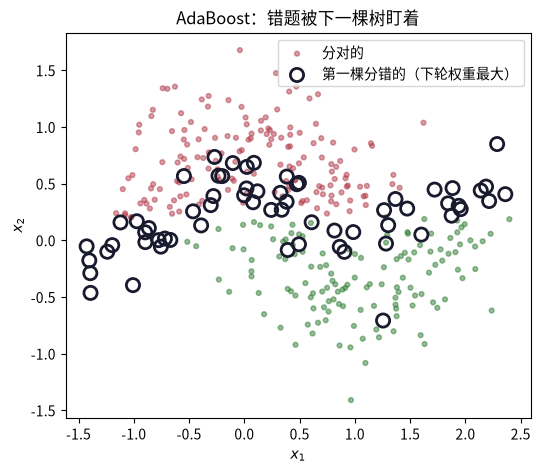

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                         n_estimators=80, random_state=0).fit(Xtr, ytr)
print("sklearn AdaBoost test：", round(ada.score(Xte, yte), 3))

# 第一棵树的误分类点（下一轮权重最大的样本）
h0 = models[0]
mis = to_pm(h0.predict(Xtr)) != to_pm(ytr)      # 找到第一棵树分错的样本
plt.figure(figsize=(6, 5))
plt.scatter(Xtr[~mis, 0], Xtr[~mis, 1], c=[["#b23a48", "#2e7d32"][v] for v in ytr[~mis]], s=12, alpha=0.5, label="分对的")  # 对mis取反，分对的样本
plt.scatter(Xtr[mis, 0], Xtr[mis, 1], c="none", edgecolors="#1a1a2e", s=90, lw=2, label="第一棵分错的（下轮权重最大）")     # 分错的样本
plt.legend(); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("AdaBoost：错题被下一棵树盯着")
plt.show()

## GBDT：不是加权，是拟合残差

AdaBoost 靠权重让下一棵树「更关注错题」；GBDT 更直接——让下一棵树去<b>预测残差</b>（y − 已有预测）。用回归演示最直观：一棵一棵地去逼近一条曲线。

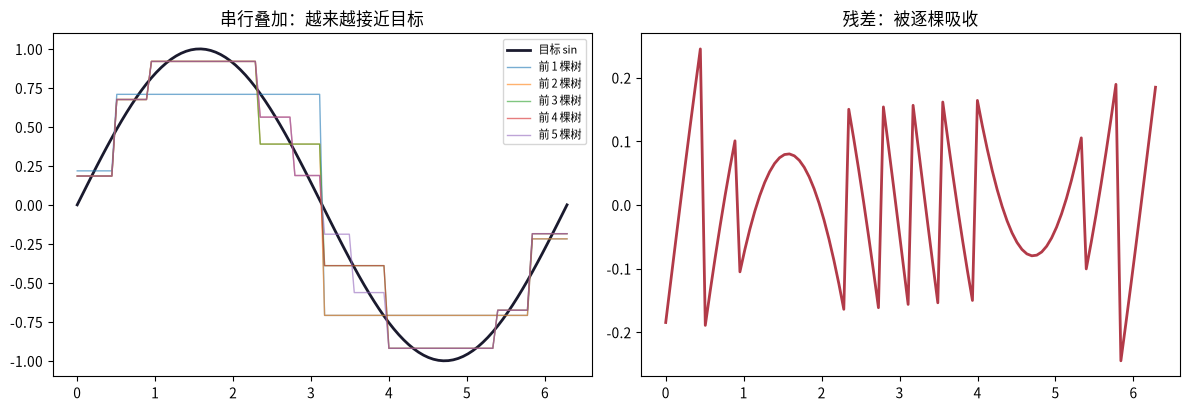

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# 目标：sin 曲线
X1 = np.linspace(0, 2 * np.pi, 100)
y1 = np.sin(X1)

residual = y1.copy()          # 初始残差 = 目标本身
trees = []
for m in range(5):
    t = DecisionTreeRegressor(max_depth=2, random_state=m).fit(X1[:, None], residual)
    # 相当于是系统的串联，将上一棵树的残差作为下一棵树y的目标值进行决策树的构建
    trees.append(t)
    residual = residual - t.predict(X1[:, None])   # 下一棵拟合剩下的残差

step = np.zeros_like(y1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(X1, y1, color="#1a1a2e", lw=2, label="目标 sin")
for m in range(5):
    step = step + trees[m].predict(X1[:, None])
    axes[0].plot(X1, step, lw=1, alpha=0.6, label=f"前 {m+1} 棵树")
axes[0].legend(fontsize=8); axes[0].set_title("串行叠加：越来越接近目标")
axes[1].plot(X1, residual, color="#b23a48", lw=2, label="最终残差（只剩噪声）")
axes[1].set_title("残差：被逐棵吸收")
plt.tight_layout(); plt.show()

## 分类上的 GBDT：完整对比

回到月牙分类。对比全部模型，注意 Boosting 家族用「浅树」，而随机森林用「深树」。

In [9]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xtr, ytr)
gbdt1 = GradientBoostingClassifier(n_estimators=100, max_depth=1, random_state=0).fit(Xtr, ytr)
gbdt3 = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=0).fit(Xtr, ytr)
gbdt5 = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=0).fit(Xtr, ytr)

for name, m in [("树桩", stump), ("深树", deep), ("随机森林", rf),
                ("AdaBoost", ada), ("GBDT depth=1", gbdt1), ("GBDT depth=3", gbdt3), ("GBDT depth=5", gbdt5)]:
    print(f"{name:14s} train {m.score(Xtr, ytr):.3f}  test {m.score(Xte, yte):.3f}")

树桩             train 0.820  test 0.800
深树             train 1.000  test 0.860
随机森林           train 1.000  test 0.887
AdaBoost       train 0.917  test 0.873
GBDT depth=1   train 0.906  test 0.873
GBDT depth=3   train 0.994  test 0.893
GBDT depth=5   train 1.000  test 0.867


## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 为什么分错的样本权重会变大？这个「针对性」和 Bagging 的「一视同仁」有什么本质区别？结合「降偏差 vs 降方差」回答。

**S2.** GBDT 拟合残差的演示里，前 3 棵树叠加后曲线已经贴近 sin——如果继续加到 20 棵会发生什么？为什么？

**M1.** 把 `fit_adaboost` 的 `M` 从 1 扫到 200，画 AdaBoost test 准确率曲线。它和随机森林（0009 的 M1）收敛后「持平」的行为一样吗？

**M2.** 把 `learning_rate` 从 0.01 扫到 1（固定 n_estimators=100），看 GBDT test 准确率变化，解释「学习率小 → 需要更多树」的权衡。

**H1.** 把 GBDT 的 `max_depth` 从 1 调到 5（固定 n_estimators=100），打印 train/test 准确率。树变深后 train/test 差距如何变化？这说明 GBDT 会过拟合吗？

**H2.** 面试题：XGBoost 相比 GBDT 做了哪几件事？（提示：二阶梯度、正则化、缺失值处理、列采样等）用一句话概括它为什么比赛常胜。

In [ ]:
# pass  # 练习区（S1/S2）
# 每一轮训练完，分类错误的样本，会增大样本权重；分对的样本降低权重。下一棵弱分类器会被迫更加关注这些被搞错的样本，努力修正之前的错误。

# AdaBoost 提高错分样本权重，让下一个弱学习器重点攻克难样本，串行迭代降低偏差；Bagging 每棵树对样本无差别对待，并行训练，依靠平均来降低方差。

In [ ]:
# pass  # 练习区（M1/M2）

# Bagging 并行平均，增加基模型不会引入过拟合；Boosting 串行迭代，迭代轮次过多会过拟合。

In [ ]:
# pass  # 练习区（H1/H2）
# GBDT 是会发生过拟合的。
# 基树本身越复杂（越深），单棵树方差越高；串行叠加，更容易记住训练噪声。所以 GBDT 实践中要限制树深度，配合学习率、正则抑制过拟合。

# XGBoost 在 GBDT 一阶梯度基础上引入二阶梯度，增加丰富正则(如 L1、L2 正则化)，内置缺失值处理、行列采样，加上工程优化，精度高、抗过拟合能力强，所以竞赛表现优异。